<a href="https://colab.research.google.com/github/VSUrhuel/forage-classifications/blob/main/Tan_%26_Lee_Algo_Efficientnet_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import numpy as np
import os
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
BASE_DIR = '/content/drive/MyDrive/Undergrad Thesis/Dataset'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'val')
SAVE_PATH = '/content/drive/MyDrive/Undergrad Thesis/Dataset/Models'

In [4]:
# ==========================================
# 1. CONFIGURATION (Matches EfficientNetV2 Paper Table 6)
# ==========================================
CONFIG = {
    'num_stages': 4,            # (M) Number of distinct stages
    'total_epochs': 40,         # Total training epochs
    'batch_size': 32,
    'num_classes': 14,          # Change to your actual class count

    # STARTING STATE (Small, Weak Reg)
    'start': {
        'size': 128,            # S0
        'dropout': 0.1,         # R0 (Dropout)
        'aug_magnitude':5,     # R0 (RandAugment Magnitude 5)
        'mixup_alpha': 0.0      # R0 (Mixup Strength)
    },

    # ENDING STATE (Large, Strong Reg)
    'end': {
        'size': 300,            # Se
        'dropout': 0.4,         # Re (Dropout)
        'aug_magnitude': 15,    # Re (RandAugment Magnitude 15)
        'mixup_alpha': 0.15      # Re (Mixup Strength)
    }
}

In [5]:
# ==========================================
# 2. HELPER: LINEAR INTERPOLATION
# ==========================================
def get_stage_params(stage_idx, total_stages, start_cfg, end_cfg):
    """
    Implements Linear Interpolation from Algorithm 1.
    Formula: Val_i = Start + (End - Start) * (i / M-1)
    """
    if total_stages == 1: return end_cfg

    ratio = stage_idx / (total_stages - 1)
    params = {}

    for key in start_cfg:
        start_val = start_cfg[key]
        end_val = end_cfg[key]
        val = start_val + (end_val - start_val) * ratio

        if key in ['size', 'aug_magnitude']:
            params[key] = int(round(val))
        else:
            params[key] = val

    return params

In [6]:
def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Calculates weighted loss"""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [7]:
# ==========================================
# 5. MIXUP UTILITIES (Use in Training Loop)
# ==========================================
def mixup_data(x, y, alpha=0.2):
    """Returns mixed inputs, pairs of targets, and lambda"""
    if alpha > 0:
        # Sample Lambda from Beta distribution (Matches Paper)
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

In [8]:
# ==========================================
# 4. PYTORCH DATA PIPELINE
# ==========================================
def get_dataloader(data_dir, img_size, aug_magnitude, batch_size):
    print(f"   -> Pipeline: Size={img_size}, RandAug={aug_magnitude}")

    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandAugment(num_ops=2, magnitude=aug_magnitude),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
    ])

    dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,       # Adjust based on your CPU cores
        pin_memory=True,     # Faster transfer to GPU
        drop_last=True       # Essential for stable Mixup shapes
    )

    return loader

In [9]:
from torchvision import models
import torch.nn as nn

def build_model(num_classes, dropout_rate):
    print(f"   -> Building PyTorch EfficientNetV2-S (Dropout={dropout_rate})")

    model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)

    num_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout_rate, inplace=True),
        nn.Linear(in_features=num_features, out_features=num_classes)
    )

    return model

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device, mixup_alpha):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        inputs, targets_a, targets_b, lam = mixup_data(inputs, labels, mixup_alpha)

        optimizer.zero_grad()
        outputs = model(inputs)

        loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(targets_a).sum().item()

    return running_loss / len(loader), correct / total * 100.00

In [11]:
# 1. Setup Global History Container
global_history = {
    'loss': [], 'accuracy': [],
    'val_loss': [], 'val_accuracy': []
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = build_model(num_classes=CONFIG['num_classes'], dropout_rate=CONFIG['start']['dropout'])
model = model.to(device)

print(f"Starting EfficientNetV2 Progressive Training [cite: 231]")

epochs_per_stage = CONFIG['total_epochs'] // CONFIG['num_stages']

for stage_i in range(CONFIG['num_stages']):
    print(f"\n=== STAGE {stage_i+1}/{CONFIG['num_stages']} ===")

    params = get_stage_params(stage_i, CONFIG['num_stages'], CONFIG['start'], CONFIG['end'])

    print(f"   -> Updating Dropout to {params['dropout']:.4f}")
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.p = params['dropout']

    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    try:
        train_loader = get_dataloader(
            TRAIN_DIR,
            params['size'],
            params['aug_magnitude'],
            CONFIG['batch_size']
        )

        val_loader = get_dataloader(
            VAL_DIR,
            params['size'],
            0,
            CONFIG['batch_size']
        )

        print(f"   -> Training with Image Size: {params['size']}x{params['size']}")

        for epoch in range(epochs_per_stage):
            train_loss, train_acc = train_one_epoch(
                model, train_loader, criterion, optimizer, device,
                mixup_alpha=params['mixup_alpha']
            )

            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item()
                    _, predicted = outputs.max(1)
                    val_total += labels.size(0)
                    val_correct += predicted.eq(labels).sum().item()

            val_loss = val_loss / len(val_loader)
            val_acc = 100. * val_correct / val_total

            global_history['loss'].append(train_loss)
            global_history['accuracy'].append(train_acc)
            global_history['val_loss'].append(val_loss)
            global_history['val_accuracy'].append(val_acc)

            print(f"   Epoch {epoch+1}/{epochs_per_stage}: "
                  f"Loss={train_loss:.4f}, Acc={train_acc:.2f}% | "
                  f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.2f}%")

        save_path = os.path.join(SAVE_PATH, f"new_ver_efficientnetv2_stage_{stage_i+1}.pth")
        torch.save(model.state_dict(), save_path)
        print(f"   -> Model Saved: {save_path}")

    except Exception as e:
        print(f"\n❌ DATA ERROR: {e}")
        # raise e # Uncomment to see full traceback
        break

print("\nTraining Complete.")

Using device: cuda
   -> Building PyTorch EfficientNetV2-S (Dropout=0.1)
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 239MB/s]


Starting EfficientNetV2 Progressive Training [cite: 231]

=== STAGE 1/4 ===
   -> Updating Dropout to 0.1000
   -> Pipeline: Size=128, RandAug=5
   -> Pipeline: Size=128, RandAug=0
   -> Training with Image Size: 128x128
   Epoch 1/10: Loss=1.8602, Acc=42.79% | Val Loss=0.8291, Val Acc=75.00%
   Epoch 2/10: Loss=0.6513, Acc=79.70% | Val Loss=0.3923, Val Acc=86.41%
   Epoch 3/10: Loss=0.3363, Acc=89.92% | Val Loss=0.2788, Val Acc=90.90%
   Epoch 4/10: Loss=0.2219, Acc=93.16% | Val Loss=0.2034, Val Acc=93.89%
   Epoch 5/10: Loss=0.1531, Acc=95.35% | Val Loss=0.2249, Val Acc=93.07%
   Epoch 6/10: Loss=0.1185, Acc=96.62% | Val Loss=0.2128, Val Acc=93.48%
   Epoch 7/10: Loss=0.0920, Acc=97.41% | Val Loss=0.2434, Val Acc=92.12%
   Epoch 8/10: Loss=0.0858, Acc=97.47% | Val Loss=0.2449, Val Acc=93.21%
   Epoch 9/10: Loss=0.0690, Acc=98.09% | Val Loss=0.2691, Val Acc=92.80%
   Epoch 10/10: Loss=0.0784, Acc=97.80% | Val Loss=0.1853, Val Acc=94.29%
   -> Model Saved: /content/drive/MyDrive/Underg

In [15]:
def load_model(path, num_classes):
    print(f"-> Loading PyTorch EfficientNetV2-S from '{path}'...")
    # Re-initialize the architecture (Must match training!)
    model = models.efficientnet_v2_s(weights=None)
    num_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2, inplace=True),
        nn.Linear(in_features=num_features, out_features=num_classes)
    )

    # Load weights
    checkpoint = torch.load(path, map_location=DEVICE)
    # Handle if checkpoint is a dict (state_dict) or full model
    if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
        model.load_state_dict(checkpoint['state_dict'])
    else:
        model.load_state_dict(checkpoint)

    model.to(DEVICE)
    model.eval()
    return model

-> Dataset found with 14 classes.
-> Loading PyTorch EfficientNetV2-S from '/content/drive/MyDrive/Undergrad Thesis/Dataset/Models/new_ver_efficientnetv2_stage_4.pth'...
🚀 Starting Inference on 781 images...

⚡ INFERENCE PERFORMANCE
Average Inference Time: 2.57 ms/image
Throughput:             389.03 FPS

📈 CLASSIFICATION REPORT
Overall Accuracy: 97.31%
------------------------------------------------------------
               precision    recall  f1-score   support

Carabao Grass     1.0000    1.0000    1.0000        56
       Centro     0.9455    1.0000    0.9720        52
    Desmodium     1.0000    0.9833    0.9916        60
     Fleminga     0.9649    1.0000    0.9821        55
   Gliricidia     1.0000    0.9828    0.9913        58
       Guinea     0.9821    0.9322    0.9565        59
   Indigofera     0.9804    0.9615    0.9709        52
        Kudzu     1.0000    0.9434    0.9709        53
     Leucaena     0.9821    1.0000    0.9910        55
       Molato     0.9828    0.98

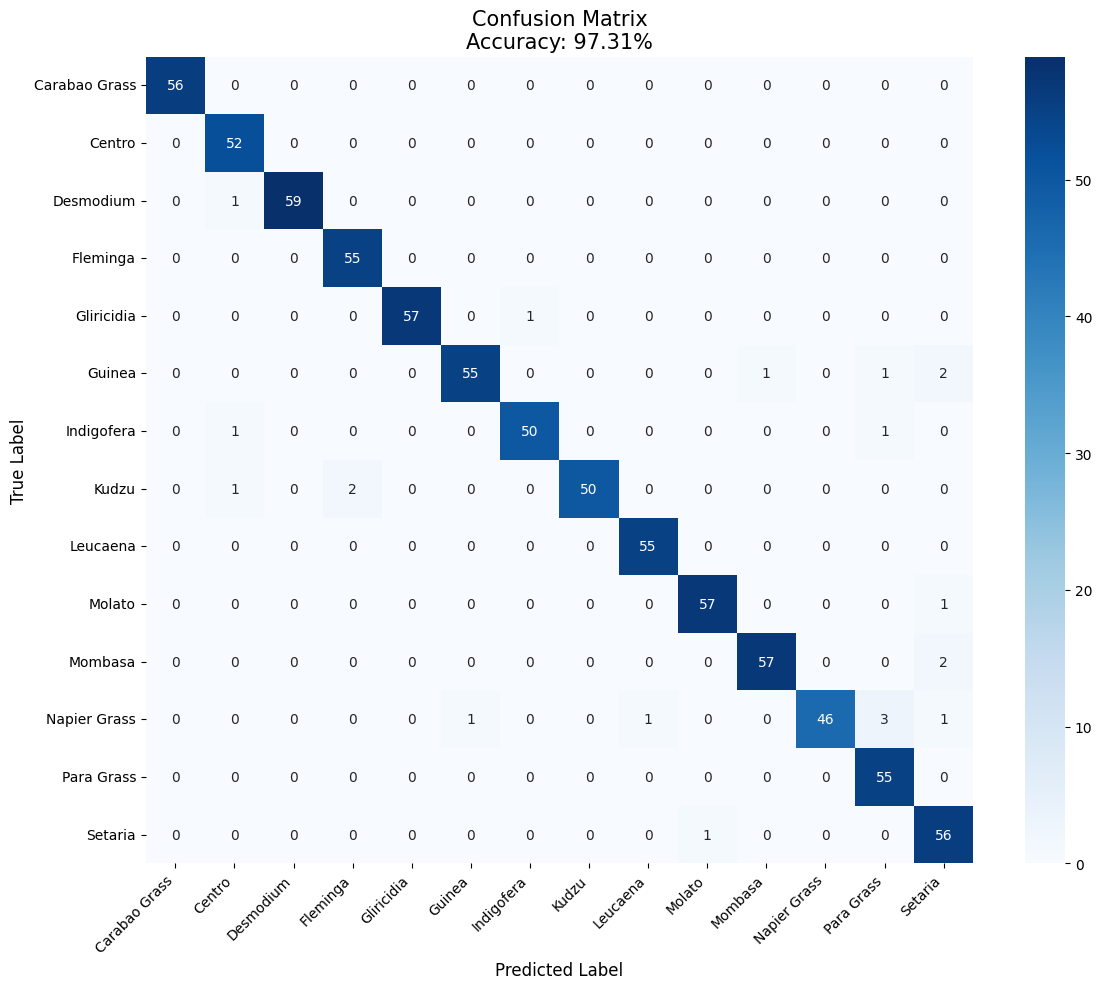

In [16]:
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np
import time
import os

# ==========================================
# 1. SETUP & MODEL LOADING
# ==========================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_PATH = os.path.join(SAVE_PATH, "new_ver_efficientnetv2_stage_4.pth")
BATCH_SIZE = 32

CLASS_NAMES = []
for class_name in os.listdir(TRAIN_DIR):
    if os.path.isdir(os.path.join(TRAIN_DIR, class_name)):
        CLASS_NAMES.append(class_name)


test_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(root=os.path.join(BASE_DIR, 'test'), transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

if len(test_dataset.classes) == len(CLASS_NAMES):
    print(f"-> Dataset found with {len(test_dataset.classes)} classes.")
else:
    print("Warning: Class count mismatch between code and dataset folder.")

model = load_model(MODEL_PATH, len(CLASS_NAMES))

all_preds = []
all_labels = []
inference_times = []

print(f"🚀 Starting Inference on {len(test_dataset)} images...")

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        # Sync CUDA for accurate timing
        if DEVICE.type == 'cuda': torch.cuda.synchronize()
        start_time = time.time()

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        if DEVICE.type == 'cuda': torch.cuda.synchronize()
        end_time = time.time()

        # Calculate time per image in this batch
        batch_time = end_time - start_time
        inference_times.append(batch_time / len(images))

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

avg_time_per_img_ms = np.mean(inference_times) * 1000
fps = 1 / np.mean(inference_times)
overall_acc = accuracy_score(all_labels, all_preds)

print("\n" + "="*30)
print("⚡ INFERENCE PERFORMANCE")
print("="*30)
print(f"Average Inference Time: {avg_time_per_img_ms:.2f} ms/image")
print(f"Throughput:             {fps:.2f} FPS")

print("\n" + "="*30)
print("📈 CLASSIFICATION REPORT")
print("="*30)
print(f"Overall Accuracy: {overall_acc*100:.2f}%")
print("-" * 60)

report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4)
print(report)

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Confusion Matrix\nAccuracy: {overall_acc*100:.2f}%', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import os

# # ==========================================
# # STAGE 4 RECOVERY CONFIGURATION
# # ==========================================
# # We manually define the parameters for the final stage (Stage 4)
# STAGE_4_PARAMS = {
#     'size': 300,            # Max Resolution
#     'dropout': 0.4,         # Max Dropout
#     'aug_magnitude': 15,    # Max Augmentation
#     'mixup_alpha': 0.2,     # Max Mixup
#     'batch_size': 32        # <--- REDUCED FROM 32 TO FIX MEMORY CRASH
# }

# # Path to the model you just saved
# CHECKPOINT_PATH = "/content/drive/MyDrive/Undergrad Thesis/Dataset/Models/efficientnetv2_stage_3.pth"
# FINAL_SAVE_PATH = "/content/drive/MyDrive/Undergrad Thesis/Dataset/Models/efficientnetv2_stage_4_final.pth"

# # ==========================================
# # RECOVERY TRAINING LOOP
# # ==========================================
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Recovering Training on {device}...")

# # 1. Build Model Architecture
# # We initialize with Stage 3 dropout (0.3) just to load weights safely,
# # but we will update it to 0.4 immediately after.
# model = build_model(num_classes=14, dropout_rate=0.3)
# model = model.to(device)

# # 2. Load the Saved Weights from Stage 3
# print(f"Loading checkpoint: {CHECKPOINT_PATH}")
# if os.path.exists(CHECKPOINT_PATH):
#     model.load_state_dict(torch.load(CHECKPOINT_PATH))
#     print("✅ Checkpoint loaded successfully. Resuming from Stage 3.")
# else:
#     raise FileNotFoundError(f"Could not find {CHECKPOINT_PATH}")

# # 3. Apply Stage 4 Settings
# print(f"Applying Stage 4 Settings: Dropout={STAGE_4_PARAMS['dropout']}, Batch={STAGE_4_PARAMS['batch_size']}")

# # Update Dropout Layers to 0.4
# for module in model.modules():
#     if isinstance(module, nn.Dropout):
#         module.p = STAGE_4_PARAMS['dropout']

# # 4. Data Loaders (With Reduced Batch Size)
# # Note: We use the same 'get_dataloader' function you already defined
# train_loader = get_dataloader(
#     TRAIN_DIR, # Make sure this variable is defined or replace with string path
#     STAGE_4_PARAMS['size'],
#     STAGE_4_PARAMS['aug_magnitude'],
#     STAGE_4_PARAMS['batch_size']
# )

# val_loader = get_dataloader(
#     VAL_DIR,   # Make sure this variable is defined
#     STAGE_4_PARAMS['size'],
#     0,         # No Augmentation for Val
#     STAGE_4_PARAMS['batch_size']
# )

# # 5. Optimizer
# optimizer = optim.Adam(model.parameters(), lr=1e-4)
# criterion = nn.CrossEntropyLoss()

# # 6. Run Final Training Loop (10 Epochs)
# print("\n=== STARTING STAGE 4 (FINAL) ===")
# for epoch in range(10): # 10 Epochs for the final stage
#     # Train
#     train_loss, train_acc = train_one_epoch(
#         model, train_loader, criterion, optimizer, device,
#         mixup_alpha=STAGE_4_PARAMS['mixup_alpha']
#     )

#     # Validate
#     model.eval()
#     val_loss = 0.0
#     val_correct = 0
#     val_total = 0
#     with torch.no_grad():
#         for inputs, labels in val_loader:
#             inputs, labels = inputs.to(device), labels.to(device)
#             outputs = model(inputs)
#             loss = criterion(outputs, labels)
#             val_loss += loss.item()
#             _, predicted = outputs.max(1)
#             val_total += labels.size(0)
#             val_correct += predicted.eq(labels).sum().item()

#     val_loss = val_loss / len(val_loader)
#     val_acc = 100. * val_correct / val_total

#     print(f"Stage 4 Epoch {epoch+1}/10: "
#           f"Loss={train_loss:.4f}, Acc={train_acc:.2f}% | "
#           f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.2f}%")

# # 7. Save Final Model
# torch.save(model.state_dict(), FINAL_SAVE_PATH)
# print(f"\n✅ THESIS COMPLETE. Final Model Saved: {FINAL_SAVE_PATH}")

In [ ]:

# print("-> Final model saved to 'effnetv2_progressive_final.pth")

# # 2. Save History to CSV (For Thesis Plotting in Excel/LaTeX)
# history_df = pd.DataFrame(global_history)
# history_df.to_csv("training_log.csv", index_label="epoch")
# print(history_df)
# print("-> Training logs saved to 'training_log.csv'")

# # 3. Plot the "Combined" History
# plt.figure(figsize=(12, 5))

# # Accuracy Plot
# plt.subplot(1, 2, 1)
# plt.plot(global_history['accuracy'], label='Train Acc')
# plt.plot(global_history['val_accuracy'], label='Val Acc')
# plt.title('Progressive Accuracy')
# plt.xlabel('Total Epochs')
# plt.ylabel('Accuracy')
# plt.legend()
# # Add vertical lines for stages
# for i in range(1, CONFIG['num_stages']):
#     plt.axvline(x=i*epochs_per_stage, color='gray', linestyle='--', alpha=0.5)

# # Loss Plot
# plt.subplot(1, 2, 2)
# plt.plot(global_history['loss'], label='Train Loss')
# plt.plot(global_history['val_loss'], label='Val Loss')
# plt.title('Progressive Loss')
# plt.xlabel('Total Epochs')
# plt.ylabel('Loss')
# plt.legend()
# for i in range(1, CONFIG['num_stages']):
#     plt.axvline(x=i*epochs_per_stage, color='gray', linestyle='--', alpha=0.5)

# plt.tight_layout()
# plt.show()

In [ ]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np
import time

MODEL_PATH = "/content/drive/MyDrive/Undergrad Thesis/Dataset/Models/best_model.pth"
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

all_preds = []
all_labels = []
inference_times = [] # Store time taken for each batch

print(f"🚀 Starting Inference on {len(val_loader.dataset)} images...")

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        if DEVICE == 'cuda': torch.cuda.synchronize()
        start_time = time.time()

        outputs = model(images)

        if DEVICE == 'cuda': torch.cuda.synchronize()
        end_time = time.time()
        # -------------------------------------------------

        # Calculate time per image in this batch
        batch_time = end_time - start_time
        inference_times.append(batch_time / len(images))

        # Get Predictions
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

avg_time_per_img = np.mean(inference_times) * 1000 # Convert to ms
fps = 1 / np.mean(inference_times)

print("\n" + "="*30)
print("⚡ INFERENCE PERFORMANCE")
print("="*30)
print(f"Average Inference Time: {avg_time_per_img:.2f} ms/image")
print(f"Throughput:             {fps:.2f} FPS")

# B. Classification Metrics
class_names = val_dataset.classes
overall_acc = accuracy_score(all_labels, all_preds)

print("\n" + "="*30)
print("📈 CLASSIFICATION REPORT")
print("="*30)
print(f"Overall Accuracy: {overall_acc*100:.2f}%")
print("-" * 60)

# Generates a table with Precision, Recall, F1-Score for EACH class
report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print(report)

# ==========================================
# 4. VISUALIZE CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(14, 12)) # Larger figure for 14 classes
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Confusion Matrix\nAccuracy: {overall_acc*100:.2f}%', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()